# A controlled nonlinear, time-varying benchmark: the forced Van der Pol oscillator

Examples `00` (LTV control) and `11` (transient pulses) drive **linear**
dynamics. The real-data pickle in `08` is nonlinear but has no ground-truth
change point. This example fills the gap with the textbook nonlinear
oscillator, an **exogenous control input**, and a *known* change point:

$$\ddot{x} - \mu(1 - x^2)\dot{x} + x = u, \qquad u(t) = F\sin(\Omega t)$$

The system is driven by an external sinusoidal input `u` — a genuine control,
independent of the state, that `OnlineDMDwC` regresses out (unlike a state
feedback `u = Kx`, which is collinear with the state and carries no
independent information). The nonlinearity strength `mu` steps from `MU_PRE`
to `MU_POST` at `t = T/2`: small `mu` is a near-linear, well-modelled regime,
so the reconstruction-error score sits near zero; the step changes the shape
of the limit cycle, and the score peaks once the post-change regime fills the
detection window. `PolynomialExtender(2)` lifts the $x^2$ term so a low-rank
linear `OnlineDMDwC` can model each regime.

In [1]:
from __future__ import annotations

import sys
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from river.decomposition import OnlineDMDwC
from river.feature_extraction import PolynomialExtender
from river.preprocessing import Hankelizer
from scipy.integrate import solve_ivp

sys.path.append("../")
from reshift.chdsubid import SubIDChangeDetector
from reshift.rolling import Rolling

if TYPE_CHECKING:
    from collections.abc import Callable

In [2]:
# Fixed configuration
T = 200.0  # total simulated time
DT = 0.05  # sampling step -> 4000 snapshots
MU_PRE = 0.3  # nonlinearity strength before the change (near-linear cycle)
MU_POST = 1.2  # nonlinearity strength after the change (clearly anharmonic)
F = 1.2  # forcing amplitude (exogenous control)
OMEGA_F = 0.7  # forcing frequency
SIGMA = 0.05  # measurement noise std

LEARN_W = 600  # rolling OnlineDMDwC window
HN = 20  # time-delay embedding order
P = 4  # state DMD rank (states are lifted by PolynomialExtender)
Q = 1  # input rank (scalar control)
DET_WIN = 300  # detection window (ref_size = test_size)


def vanderpol(mu: float) -> Callable[[float, np.ndarray], list[float]]:
    """Return the forced Van der Pol RHS f(t, [x, v]) with input u = F*sin(OMEGA_F*t)."""

    def f(t: float, s: np.ndarray) -> list[float]:
        x, v = s
        u = F * np.sin(OMEGA_F * t)
        return [v, mu * (1 - x**2) * v - x + u]

    return f


def simulate(seed: int = 42) -> tuple[pd.DataFrame, pd.DataFrame, int]:
    """Integrate forced Van der Pol with a mu-step at t=T/2.

    Returns (states, inputs, cp index).
    """
    t = np.arange(0, T, DT)
    cp = len(t) // 2
    kw = {"rtol": 1e-8, "atol": 1e-8}
    pre = solve_ivp(
        vanderpol(MU_PRE),
        (t[0], t[cp]),
        [2.0, 0.0],
        t_eval=t[:cp],
        **kw,
    )
    post = solve_ivp(
        vanderpol(MU_POST),
        (t[cp], t[-1]),
        pre.y[:, -1],
        t_eval=t[cp:],
        **kw,
    )
    x = np.hstack([pre.y, post.y]).T
    rng = np.random.default_rng(seed)
    x += rng.normal(0, SIGMA, x.shape)
    states = pd.DataFrame(x, columns=pd.Index(["$x$", "$\\dot{x}$"]))
    inputs = pd.DataFrame(
        {"$u$": F * np.sin(OMEGA_F * t)},
    )  # exogenous control
    return states, inputs, cp


def score_over_time(states: pd.DataFrame, inputs: pd.DataFrame) -> np.ndarray:
    """Run controlled ODMD-CPD over the stream; return the per-sample score trace."""
    odmd = Rolling(
        OnlineDMDwC(
            p=P,
            q=Q,
            initialize=LEARN_W - 1,
            w=1.0,
            exponential_weighting=False,
            eig_rtol=None,
        ),
        LEARN_W,
    )
    det = SubIDChangeDetector(
        odmd,
        ref_size=DET_WIN,
        test_size=DET_WIN,
        grace_period=LEARN_W + DET_WIN + 1,
        start_soon=True,
    )
    pipe = PolynomialExtender(2) | Hankelizer(HN) | det
    s = np.zeros(len(states))
    rows = zip(
        states.to_dict(orient="records"),
        inputs.to_dict(orient="records"),
        strict=True,
    )
    for i, (xi, ui) in enumerate(rows):
        try:
            s[i] = pipe.score_one(xi)
        except ZeroDivisionError:  # degenerate reference (numerical fragility)
            s[i] = s[i - 1] if i else 0.0
        pipe.learn_one(xi, u=ui)
    return np.nan_to_num(s)

## Abrupt change: nonlinearity strength steps at the midpoint, under exogenous forcing

The score sits near zero while the model tracks the first (near-linear) forced
cycle, then peaks once the post-change regime fills the detection window. The
peak lags the true change by roughly one detection window — the expected
detection latency, not a miss.

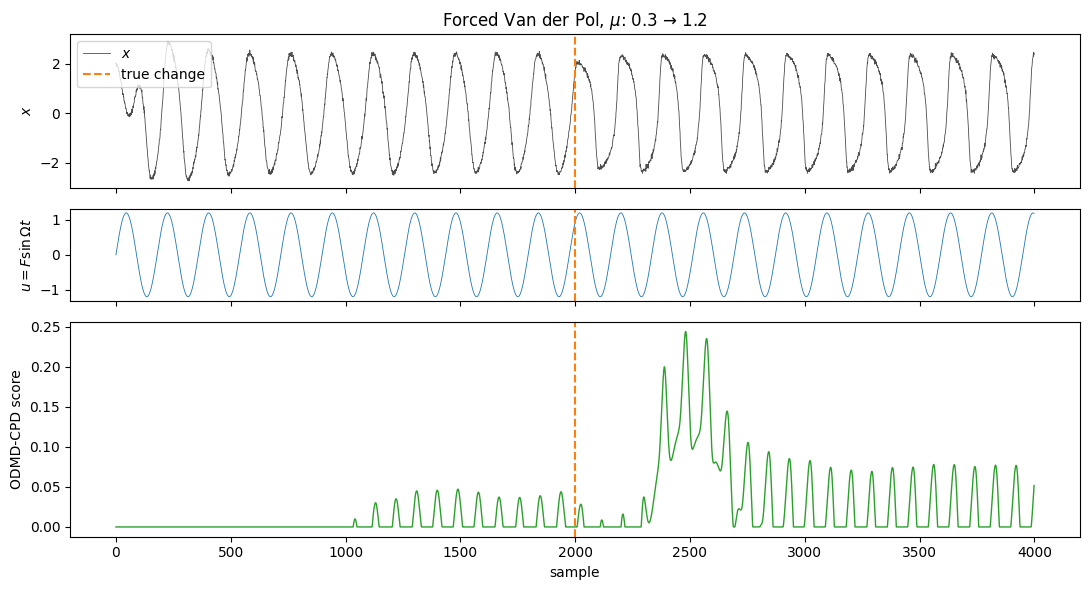

In [3]:
states, inputs, cp = simulate()
scores = score_over_time(states, inputs)

fig, (ax_sig, ax_u, ax_sc) = plt.subplots(
    3,
    1,
    figsize=(11, 6),
    sharex=True,
    height_ratios=[1, 0.6, 1.4],
)
ax_sig.plot(states["$x$"].to_numpy(), lw=0.6, color="0.3", label="$x$")
ax_sig.axvline(cp, color="C1", ls="--", label="true change")
ax_sig.set(
    ylabel="$x$",
    title=f"Forced Van der Pol, $\\mu$: {MU_PRE} → {MU_POST}",
)
ax_sig.legend(loc="upper left")

ax_u.plot(inputs["$u$"].to_numpy(), lw=0.6, color="C0")
ax_u.axvline(cp, color="C1", ls="--")
ax_u.set(ylabel="$u = F\\sin\\Omega t$")

ax_sc.plot(scores, lw=1.0, color="C2")
ax_sc.axvline(cp, color="C1", ls="--")
ax_sc.set(xlabel="sample", ylabel="ODMD-CPD score")
fig.tight_layout()
plt.show()

In [4]:
# Self-check: the change must produce a clear, localised response — the
# post-change peak well above the pre-change baseline, and located after the
# true change point (allowing for detection latency).
base_max = scores[LEARN_W + DET_WIN + 1 : cp].max()
post = scores[cp:]
assert post.max() > 2.0 * base_max, (
    "change response not clearly above baseline"
)
assert post.argmax() + cp > cp, "peak does not follow the change point"
print(
    f"ok: peak {post.max():.3f} at sample {post.argmax() + cp} "
    f"vs baseline max {base_max:.3f} ({post.max() / base_max:.1f}x)",
)

ok: peak 0.244 at sample 2481 vs baseline max 0.047 (5.2x)
